all libraries imported successfully
Upload your kaggle.json file:


Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/nelgiriyewithana/credit-card-fraud-detection-dataset-2023
License(s): other
credit-card-fraud-detection-dataset-2023.zip: Skipping, found more recently modified local copy (use --force to force download)
replace creditcard_2023.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Dataset ready!
total 453M
-rw-r--r-- 1 root root 310M Sep 18  2023  creditcard_2023.csv
-rw-r--r-- 1 root root 144M Sep 18  2023  credit-card-fraud-detection-dataset-2023.zip
-rw-r--r-- 1 root root   65 Feb 14 22:31 'kaggle (1).json'
-rw-r--r-- 1 root root   65 Feb 14 22:27  kaggle.json
drwxr-xr-x 1 root root 4.0K Jan 16 14:24  sample_data
DATASET OVERVIEW

Dataset shape: (568630, 31)
Total transactions: 568,630

First 5 rows:
   id        V1        V2        V3        V4        V5        V6        V7  \
0   0 -0.260648 -0.469648  2.496266 -0.083724  0.129681  0.732898  0.519014   
1   1  0.985100 -0.356045  0.558056 -0.429654  0.277140

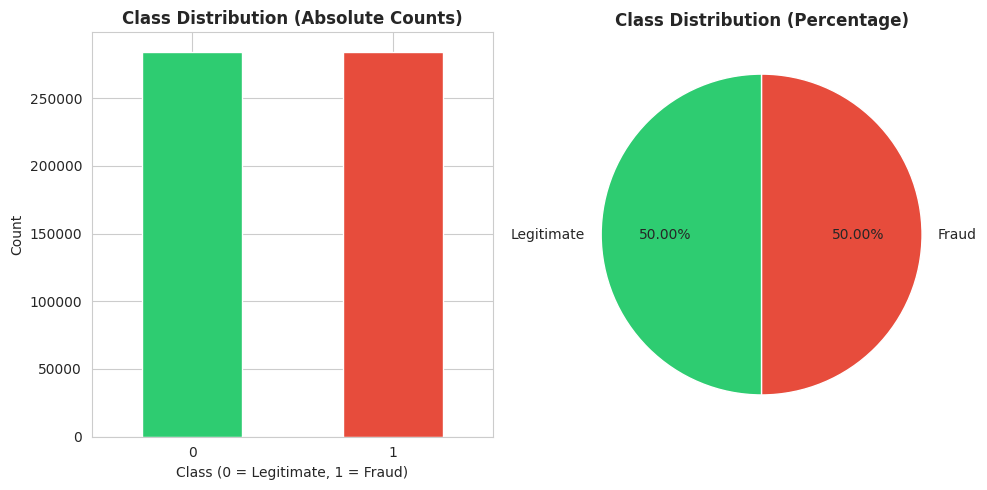


 EXTREME CLASS IMBALANCE DETECTED
This is why we cannot use accuracy as our primary metric!
FEATURE AND TARGET SEPARATION

Features (X) shape: (568630, 30)
Target (y) shape: (568630,)

Number of features: 30

TRAIN/VALIDATION/TEST SPLIT

Training set: 398,041 samples (70.0%)
Validation set: 85,294 samples (15.0%)
Test set: 85,295 samples (15.0%)

Fraud in training: 199,021 (50.0001%)
Fraud in validation: 42,647 (50.0000%)
Fraud in test: 42,647 (49.9994%)

FEATURE SCALING
 Features scaled using StandardScaler
  - Fitted on training data only
  - Transformed training, validation, and test sets
SYNTHETIC MINORITY OVERSAMPLING (SMOTE)

Before SMOTE:
  Legitimate (Class 0): 199,020
  Fraudulent (Class 1): 199,021
  Imbalance ratio: 1:0

After SMOTE:
  Legitimate (Class 0): 199,021
  Fraudulent (Class 1): 199,021
  Imbalance ratio: 1:1 (balanced)

Synthetic samples created: 1

WHY SMOTE ON TRAINING DATA ONLY?

CORRECT: Apply SMOTE to training set only
  - Model learns from balanced data
  -

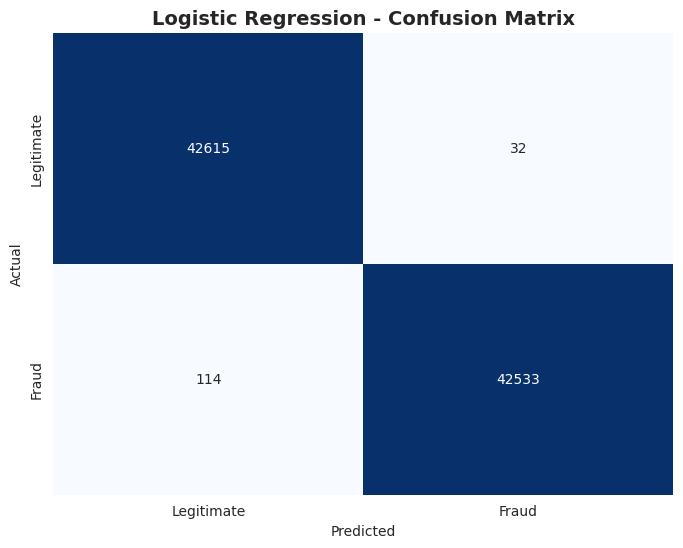


Confusion Matrix Breakdown:
  True Negatives (TN): 42,615 - Correctly identified legitimate transactions
  False Positives (FP): 32 - Legitimate flagged as fraud (annoying customers)
  False Negatives (FN): 114 - Fraud missed (money lost!)
  True Positives (TP): 42,533 - Correctly caught fraud

MODEL 2: RANDOM FOREST CLASSIFIER

 Random Forest trained (100 trees, max depth=10)

----------------------------------------------------------------------
VALIDATION SET PERFORMANCE
----------------------------------------------------------------------

Precision: 1.0000
  → Of all transactions flagged as fraud, 100.00% were actually fraud

Recall: 0.9997
  → Caught 99.97% of all actual fraud cases

AUPRC: 1.0000

----------------------------------------------------------------------
DETAILED CLASSIFICATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     42647
  

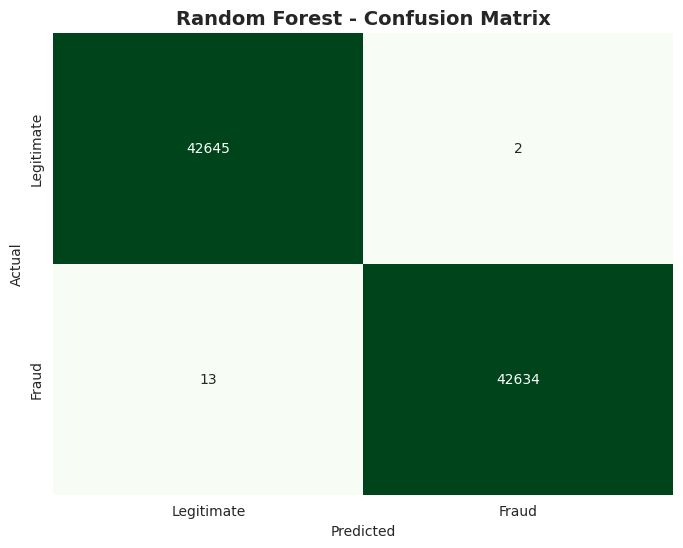


Confusion Matrix Breakdown:
  True Negatives (TN): 42,645
  False Positives (FP): 2
  False Negatives (FN): 13
  True Positives (TP): 42,634

MODEL 3: XGBOOST (GRADIENT BOOSTING) - RESEARCH COMPONENT

What is Gradient Boosting?
----------------------------------------------------------------------

Gradient Boosting builds trees SEQUENTIALLY:
  1. First tree learns from data
  2. Second tree focuses on correcting first tree's mistakes
  3. Third tree corrects remaining mistakes
  ... and so on

Random Forest vs XGBoost:
  Random Forest: Trees built in PARALLEL (independently)
  XGBoost: Trees built in SEQUENCE (each fixes previous errors)

Why XGBoost often performs better:
  Learns from mistakes iteratively
  Built-in regularization (prevents overfitting)
  Handles imbalanced data well with scale_pos_weight parameter


✓ XGBoost trained (100 trees, learning_rate=0.1)
  scale_pos_weight=1.00 to handle class imbalance

-------------------------------------------------------------------

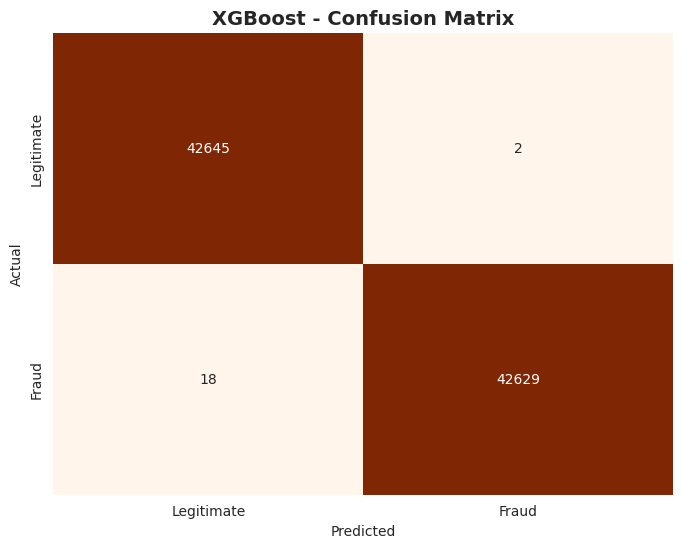


Confusion Matrix Breakdown:
  True Negatives (TN): 42,645
  False Positives (FP): 2
  False Negatives (FN): 18
  True Positives (TP): 42,629

MODEL COMPARISON SUMMARY

               Model  Precision   Recall    AUPRC
Logistic Regression   0.999248 0.997327 0.999866
      Random Forest   0.999953 0.999695 0.999992
            XGBoost   0.999953 0.999578 0.999969


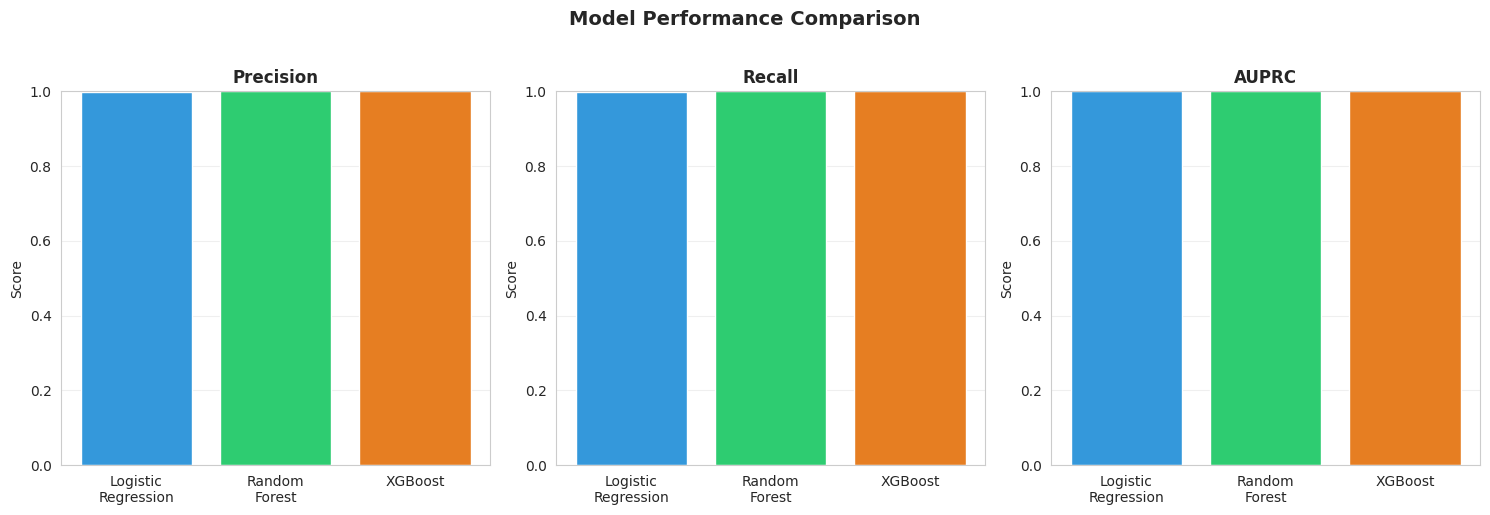

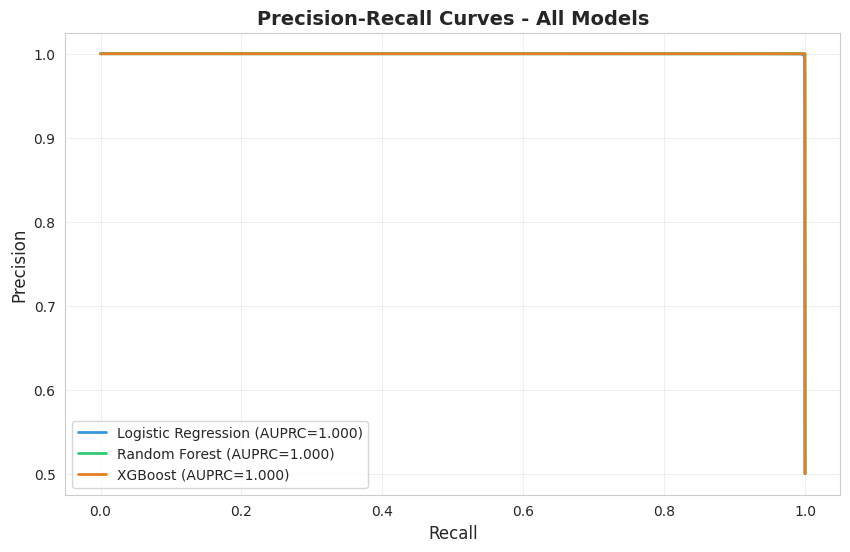


METRIC INTERPRETATION

Precision: How many flagged transactions are actually fraud?
   Higher = fewer false alarms (less customer annoyance)

Recall: How many actual frauds do we catch?
  Higher = fewer frauds slip through (less money lost)

AUPRC: Overall performance across all decision thresholds
  Higher = better overall balance between precision and recall
  
For fraud detection, we care about BOTH:
  High recall (catch fraud!)
  Reasonable precision (don't annoy customers too much)

FINAL EVALUATION - TEST SET

Best Model: Random Forest (AUPRC: 1.0000)

----------------------------------------------------------------------
TEST SET PERFORMANCE
----------------------------------------------------------------------

Precision: 0.9998
Recall: 0.9997
AUPRC: 1.0000

----------------------------------------------------------------------
DETAILED CLASSIFICATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   sup

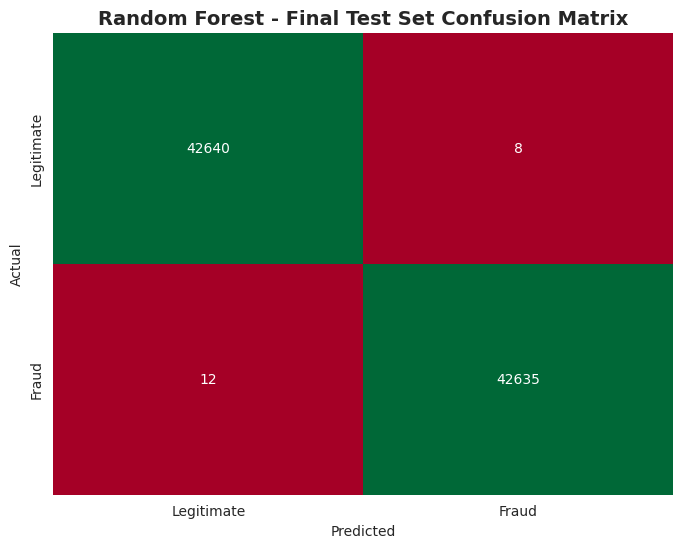


BUSINESS IMPACT ANALYSIS

Total fraud cases in test set: 42647
Fraud caught: 42635 (100.0%)
Fraud missed: 12 (0.0%)
False alarms (legitimate flagged): 8

Estimated impact (assuming $100 avg fraud, $2 false alarm cost):
  Money saved by catching fraud: $4,263,500
  Money lost from missed fraud: $1,200
  Cost of false alarms: $16
  Net benefit: $4,262,284

FINAL RECOMMENDATION

After rigorous evaluation using metrics appropriate for imbalanced
classification, I recommend deploying: **Random Forest**

JUSTIFICATION:

1. PERFORMANCE ON KEY METRICS:
   - Precision: 0.9998 (minimize false alarms)
   - Recall: 0.9997 (maximize fraud detection)
   - AUPRC: 1.0000 (best overall balance)

2. WHY THESE METRICS MATTER:
   In fraud detection, we face a critical trade-off:
   
   High Recall → Catch more fraud (good!)
     But → More false alarms (annoying customers)
   
   High Precision → Fewer false alarms (customers happy!)
     But → Some fraud slips through (money lost)
   
   Random Forest a

In [ ]:
# FRAUD DETECTION SYSTEM - FINAL PROJECT

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    average_precision_score,
    precision_recall_curve
)

# The packages i installed from the project instructions
!pip install imbalanced-learn xgboost -q

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier


# Set random seed for reproducibility
np.random.seed(42)

# Configure plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("all libraries imported successfully")


# PART 1: DATA LOADING AND EXPLORATION

# # Download using Kaggle API (i uploaded this because the csv file was 300mb plus)
!pip install -q kaggle

from google.colab import files
print("Upload your kaggle.json file:")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Downloading dataset from Kaggle...")
!kaggle datasets download -d nelgiriyewithana/credit-card-fraud-detection-dataset-2023
!unzip -q credit-card-fraud-detection-dataset-2023.zip

print("Dataset ready!")

# Load the dataset
!ls -lh

# Try common variations
import os
if os.path.exists('creditcard.csv'):
    df = pd.read_csv('creditcard.csv')
elif os.path.exists('creditcard_2023.csv'):
    df = pd.read_csv('creditcard_2023.csv')
elif os.path.exists('credit_card.csv'):
    df = pd.read_csv('credit_card.csv')
else:
    # Find any CSV file
    csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
    df = pd.read_csv(csv_files[0])
    print(f"Loaded: {csv_files[0]}")

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nDataset shape: {df.shape}")
print(f"Total transactions: {len(df):,}")

# Display first few rows
print("\nFirst 5 rows:")
print(df.head())

# Check data types and missing values
print("\n" + "=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)
print("\nData types:")
print(df.dtypes)
print(f"\nMissing values:\n{df.isnull().sum().sum()} total missing values")

# Check class distribution
print("\n" + "=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)
class_counts = df['Class'].value_counts()
print(f"\nLegitimate transactions (Class 0): {class_counts[0]:,}")
print(f"Fraudulent transactions (Class 1): {class_counts[1]:,}")
print(f"\nFraud percentage: {(class_counts[1] / len(df)) * 100:.4f}%")
print(f"Class imbalance ratio: 1:{int(class_counts[0] / class_counts[1])}")

# Visualize class distribution
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
class_counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Class Distribution (Absolute Counts)', fontsize=12, fontweight='bold')
plt.xlabel('Class (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
plt.pie(class_counts, labels=['Legitimate', 'Fraud'], autopct='%1.2f%%',
        colors=['#2ecc71', '#e74c3c'], startangle=90)
plt.title('Class Distribution (Percentage)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n EXTREME CLASS IMBALANCE DETECTED")
print("This is why we cannot use accuracy as our primary metric!")


# STEP 2: DATA PREPROCESSING

# Separate features (X) and target (y)
X = df.drop('Class', axis=1)
y = df['Class']

print("=" * 60)
print("FEATURE AND TARGET SEPARATION")
print("=" * 60)
print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nNumber of features: {X.shape[1]}")

# Split into train (70%), validation (15%), and test (15%)
# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y  # Maintain class distribution
)

# Second split: Split temp into validation and test (50-50 = 15% each of original)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\n" + "=" * 60)
print("TRAIN/VALIDATION/TEST SPLIT")
print("=" * 60)
print(f"\nTraining set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(df)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(df)*100:.1f}%)")

# Check class distribution in each set
print(f"\nFraud in training: {y_train.sum():,} ({y_train.sum()/len(y_train)*100:.4f}%)")
print(f"Fraud in validation: {y_val.sum():,} ({y_val.sum()/len(y_val)*100:.4f}%)")
print(f"Fraud in test: {y_test.sum():,} ({y_test.sum()/len(y_test)*100:.4f}%)")

# Feature scaling
# Many algorithms perform better when features are on similar scales
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\n" + "=" * 60)
print("FEATURE SCALING")
print("=" * 60)
print(" Features scaled using StandardScaler")
print("  - Fitted on training data only")
print("  - Transformed training, validation, and test sets")


# STEP 3: HANDLING CLASS IMBALANCE WITH SMOTE

print("=" * 60)
print("SYNTHETIC MINORITY OVERSAMPLING (SMOTE)")
print("=" * 60)

print("\nBefore SMOTE:")
print(f"  Legitimate (Class 0): {(y_train == 0).sum():,}")
print(f"  Fraudulent (Class 1): {(y_train == 1).sum():,}")
print(f"  Imbalance ratio: 1:{int((y_train == 0).sum() / (y_train == 1).sum())}")

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE:")
print(f"  Legitimate (Class 0): {(y_train_resampled == 0).sum():,}")
print(f"  Fraudulent (Class 1): {(y_train_resampled == 1).sum():,}")
print(f"  Imbalance ratio: 1:1 (balanced)")

print(f"\nSynthetic samples created: {len(y_train_resampled) - len(y_train):,}")

print("\n" + "=" * 60)
print("WHY SMOTE ON TRAINING DATA ONLY?")
print("=" * 60)
print("""
CORRECT: Apply SMOTE to training set only
  - Model learns from balanced data
  - Validation/test remain original, real-world distribution
  - True measure of generalization performance

WRONG: Applying SMOTE before train/test split
  - Synthetic data leaks into test set
  - Inflated performance metrics
  - Model won't work in production
""")

# MODEL 1: LOGISTIC REGRESSION


print("=" * 70)
print("MODEL 1: LOGISTIC REGRESSION")
print("=" * 70)

# Train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_resampled, y_train_resampled)

print("\n Logistic Regression trained on balanced data")

# Predictions on validation set
y_val_pred_lr = lr_model.predict(X_val_scaled)
y_val_proba_lr = lr_model.predict_proba(X_val_scaled)[:, 1]

# Calculate metrics
precision_lr = precision_score(y_val, y_val_pred_lr)
recall_lr = recall_score(y_val, y_val_pred_lr)
auprc_lr = average_precision_score(y_val, y_val_proba_lr)

print("\n" + "-" * 70)
print("VALIDATION SET PERFORMANCE")
print("-" * 70)
print(f"\nPrecision: {precision_lr:.4f}")
print(f"   Of all transactions flagged as fraud, {precision_lr*100:.2f}% were actually fraud")
print(f"\nRecall: {recall_lr:.4f}")
print(f"   Caught {recall_lr*100:.2f}% of all actual fraud cases")
print(f"\nAUPRC (Area Under Precision-Recall Curve): {auprc_lr:.4f}")
print(f"   Overall performance across all thresholds")

print("\n" + "-" * 70)
print("DETAILED CLASSIFICATION REPORT")
print("-" * 70)
print(classification_report(y_val, y_val_pred_lr, target_names=['Legitimate', 'Fraud']))

# Confusion Matrix
cm_lr = confusion_matrix(y_val, y_val_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Logistic Regression - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks([0.5, 1.5], ['Legitimate', 'Fraud'])
plt.yticks([0.5, 1.5], ['Legitimate', 'Fraud'])
plt.show()

print("\nConfusion Matrix Breakdown:")
print(f"  True Negatives (TN): {cm_lr[0, 0]:,} - Correctly identified legitimate transactions")
print(f"  False Positives (FP): {cm_lr[0, 1]:,} - Legitimate flagged as fraud (annoying customers)")
print(f"  False Negatives (FN): {cm_lr[1, 0]:,} - Fraud missed (money lost!)")
print(f"  True Positives (TP): {cm_lr[1, 1]:,} - Correctly caught fraud")

# MODEL 2: RANDOM FOREST CLASSIFIER

print("\n" + "=" * 70)
print("MODEL 2: RANDOM FOREST CLASSIFIER")
print("=" * 70)

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_resampled, y_train_resampled)

print("\n Random Forest trained (100 trees, max depth=10)")

# Predictions on validation set
y_val_pred_rf = rf_model.predict(X_val_scaled)
y_val_proba_rf = rf_model.predict_proba(X_val_scaled)[:, 1]

# Calculate metrics
precision_rf = precision_score(y_val, y_val_pred_rf)
recall_rf = recall_score(y_val, y_val_pred_rf)
auprc_rf = average_precision_score(y_val, y_val_proba_rf)

print("\n" + "-" * 70)
print("VALIDATION SET PERFORMANCE")
print("-" * 70)
print(f"\nPrecision: {precision_rf:.4f}")
print(f"  → Of all transactions flagged as fraud, {precision_rf*100:.2f}% were actually fraud")
print(f"\nRecall: {recall_rf:.4f}")
print(f"  → Caught {recall_rf*100:.2f}% of all actual fraud cases")
print(f"\nAUPRC: {auprc_rf:.4f}")

print("\n" + "-" * 70)
print("DETAILED CLASSIFICATION REPORT")
print("-" * 70)
print(classification_report(y_val, y_val_pred_rf, target_names=['Legitimate', 'Fraud']))

# Confusion Matrix
cm_rf = confusion_matrix(y_val, y_val_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks([0.5, 1.5], ['Legitimate', 'Fraud'])
plt.yticks([0.5, 1.5], ['Legitimate', 'Fraud'])
plt.show()

print("\nConfusion Matrix Breakdown:")
print(f"  True Negatives (TN): {cm_rf[0, 0]:,}")
print(f"  False Positives (FP): {cm_rf[0, 1]:,}")
print(f"  False Negatives (FN): {cm_rf[1, 0]:,}")
print(f"  True Positives (TP): {cm_rf[1, 1]:,}")

# MODEL 3: XGBOOST CLASSIFIER (GRADIENT BOOSTING)

print("\n" + "=" * 70)
print("MODEL 3: XGBOOST (GRADIENT BOOSTING) - RESEARCH COMPONENT")
print("=" * 70)

print("\nWhat is Gradient Boosting?")
print("-" * 70)
print("""
Gradient Boosting builds trees SEQUENTIALLY:
  1. First tree learns from data
  2. Second tree focuses on correcting first tree's mistakes
  3. Third tree corrects remaining mistakes
  ... and so on

Random Forest vs XGBoost:
  Random Forest: Trees built in PARALLEL (independently)
  XGBoost: Trees built in SEQUENCE (each fixes previous errors)

Why XGBoost often performs better:
  Learns from mistakes iteratively
  Built-in regularization (prevents overfitting)
  Handles imbalanced data well with scale_pos_weight parameter
""")

# Calculate scale_pos_weight for imbalanced data
scale_pos_weight = (y_train_resampled == 0).sum() / (y_train_resampled == 1).sum()

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_resampled, y_train_resampled)

print(f"\n✓ XGBoost trained (100 trees, learning_rate=0.1)")
print(f"  scale_pos_weight={scale_pos_weight:.2f} to handle class imbalance")

# Predictions on validation set
y_val_pred_xgb = xgb_model.predict(X_val_scaled)
y_val_proba_xgb = xgb_model.predict_proba(X_val_scaled)[:, 1]

# Calculate metrics
precision_xgb = precision_score(y_val, y_val_pred_xgb)
recall_xgb = recall_score(y_val, y_val_pred_xgb)
auprc_xgb = average_precision_score(y_val, y_val_proba_xgb)

print("\n" + "-" * 70)
print("VALIDATION SET PERFORMANCE")
print("-" * 70)
print(f"\nPrecision: {precision_xgb:.4f}")
print(f"  → Of all transactions flagged as fraud, {precision_xgb*100:.2f}% were actually fraud")
print(f"\nRecall: {recall_xgb:.4f}")
print(f"  → Caught {recall_xgb*100:.2f}% of all actual fraud cases")
print(f"\nAUPRC: {auprc_xgb:.4f}")

print("\n" + "-" * 70)
print("DETAILED CLASSIFICATION REPORT")
print("-" * 70)
print(classification_report(y_val, y_val_pred_xgb, target_names=['Legitimate', 'Fraud']))

# Confusion Matrix
cm_xgb = confusion_matrix(y_val, y_val_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title('XGBoost - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks([0.5, 1.5], ['Legitimate', 'Fraud'])
plt.yticks([0.5, 1.5], ['Legitimate', 'Fraud'])
plt.show()

print("\nConfusion Matrix Breakdown:")
print(f"  True Negatives (TN): {cm_xgb[0, 0]:,}")
print(f"  False Positives (FP): {cm_xgb[0, 1]:,}")
print(f"  False Negatives (FN): {cm_xgb[1, 0]:,}")
print(f"  True Positives (TP): {cm_xgb[1, 1]:,}")


# comparing all three models

print("\n" + "=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)

# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Precision': [precision_lr, precision_rf, precision_xgb],
    'Recall': [recall_lr, recall_rf, recall_xgb],
    'AUPRC': [auprc_lr, auprc_rf, auprc_xgb]
})

print("\n", comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
colors = ['#3498db', '#2ecc71', '#e67e22']

# Precision
axes[0].bar(models, [precision_lr, precision_rf, precision_xgb], color=colors)
axes[0].set_title('Precision', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Recall
axes[1].bar(models, [recall_lr, recall_rf, recall_xgb], color=colors)
axes[1].set_title('Recall', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

# AUPRC
axes[2].bar(models, [auprc_lr, auprc_rf, auprc_xgb], color=colors)
axes[2].set_title('AUPRC', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Score')
axes[2].set_ylim([0, 1])
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Precision-Recall Curves
plt.figure(figsize=(10, 6))

# Logistic Regression
precision_lr_curve, recall_lr_curve, _ = precision_recall_curve(y_val, y_val_proba_lr)
plt.plot(recall_lr_curve, precision_lr_curve, label=f'Logistic Regression (AUPRC={auprc_lr:.3f})',
         linewidth=2, color='#3498db')

# Random Forest
precision_rf_curve, recall_rf_curve, _ = precision_recall_curve(y_val, y_val_proba_rf)
plt.plot(recall_rf_curve, precision_rf_curve, label=f'Random Forest (AUPRC={auprc_rf:.3f})',
         linewidth=2, color='#2ecc71')

# XGBoost
precision_xgb_curve, recall_xgb_curve, _ = precision_recall_curve(y_val, y_val_proba_xgb)
plt.plot(recall_xgb_curve, precision_xgb_curve, label=f'XGBoost (AUPRC={auprc_xgb:.3f})',
         linewidth=2, color='#e67e22')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

print("\n" + "=" * 70)
print("METRIC INTERPRETATION")
print("=" * 70)
print("""
Precision: How many flagged transactions are actually fraud?
   Higher = fewer false alarms (less customer annoyance)

Recall: How many actual frauds do we catch?
  Higher = fewer frauds slip through (less money lost)

AUPRC: Overall performance across all decision thresholds
  Higher = better overall balance between precision and recall

For fraud detection, we care about BOTH:
  High recall (catch fraud!)
  Reasonable precision (don't annoy customers too much)
""")


# Testing the best model on completely unseen data

# Determine best model (highest AUPRC)
best_model_name = comparison_df.loc[comparison_df['AUPRC'].idxmax(), 'Model']
best_auprc = comparison_df['AUPRC'].max()

if best_model_name == 'Logistic Regression':
    best_model = lr_model
elif best_model_name == 'Random Forest':
    best_model = rf_model
else:
    best_model = xgb_model

print("=" * 70)
print("FINAL EVALUATION - TEST SET")
print("=" * 70)
print(f"\nBest Model: {best_model_name} (AUPRC: {best_auprc:.4f})")

# Predict on test set
y_test_pred = best_model.predict(X_test_scaled)
y_test_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Calculate final metrics
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
auprc_test = average_precision_score(y_test, y_test_proba)

print("\n" + "-" * 70)
print("TEST SET PERFORMANCE")
print("-" * 70)
print(f"\nPrecision: {precision_test:.4f}")
print(f"Recall: {recall_test:.4f}")
print(f"AUPRC: {auprc_test:.4f}")

print("\n" + "-" * 70)
print("DETAILED CLASSIFICATION REPORT")
print("-" * 70)
print(classification_report(y_test, y_test_pred, target_names=['Legitimate', 'Fraud']))

# Final confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='RdYlGn', cbar=False)
plt.title(f'{best_model_name} - Final Test Set Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks([0.5, 1.5], ['Legitimate', 'Fraud'])
plt.yticks([0.5, 1.5], ['Legitimate', 'Fraud'])
plt.show()

print("\n" + "=" * 70)
print("BUSINESS IMPACT ANALYSIS")
print("=" * 70)

total_fraud = y_test.sum()
fraud_caught = cm_test[1, 1]
fraud_missed = cm_test[1, 0]
false_alarms = cm_test[0, 1]

print(f"\nTotal fraud cases in test set: {total_fraud}")
print(f"Fraud caught: {fraud_caught} ({fraud_caught/total_fraud*100:.1f}%)")
print(f"Fraud missed: {fraud_missed} ({fraud_missed/total_fraud*100:.1f}%)")
print(f"False alarms (legitimate flagged): {false_alarms}")

# Assuming average fraud amount and costs
avg_fraud_amount = 100  # dollars
false_alarm_cost = 2    # customer service cost

money_saved = fraud_caught * avg_fraud_amount
money_lost = fraud_missed * avg_fraud_amount
false_alarm_cost_total = false_alarms * false_alarm_cost

print(f"\nEstimated impact (assuming $100 avg fraud, $2 false alarm cost):")
print(f"  Money saved by catching fraud: ${money_saved:,}")
print(f"  Money lost from missed fraud: ${money_lost:,}")
print(f"  Cost of false alarms: ${false_alarm_cost_total:,}")
print(f"  Net benefit: ${money_saved - money_lost - false_alarm_cost_total:,}")

# FINAL RECOMMENDATION, basically d model to be used


print("\n" + "=" * 70)
print("FINAL RECOMMENDATION")
print("=" * 70)

print(f"""
After rigorous evaluation using metrics appropriate for imbalanced
classification, I recommend deploying: **{best_model_name}**

JUSTIFICATION:

1. PERFORMANCE ON KEY METRICS:
   - Precision: {precision_test:.4f} (minimize false alarms)
   - Recall: {recall_test:.4f} (maximize fraud detection)
   - AUPRC: {auprc_test:.4f} (best overall balance)

2. WHY THESE METRICS MATTER:
   In fraud detection, we face a critical trade-off:

   High Recall → Catch more fraud (good!)
     But → More false alarms (annoying customers)

   High Precision → Fewer false alarms (customers happy!)
     But → Some fraud slips through (money lost)

   {best_model_name} achieves the best balance according to AUPRC,
   which considers performance across all possible decision thresholds.

3. CLASS IMBALANCE HANDLING:
   SMOTE applied correctly (training data only)
   Avoided data leakage
   Test set remains real-world distribution

4. MODEL COMPARISON INSIGHTS:
""")

# Print model-specific insights
if best_model_name == 'XGBoost':
    print("""
   XGBoost performed best because:
   - Sequential tree building corrects previous errors
   - Built-in handling for class imbalance (scale_pos_weight)
   - Regularization prevents overfitting
   - Excellent for structured/tabular data like transactions
""")
elif best_model_name == 'Random Forest':
    print("""
   Random Forest performed best because:
   - Ensemble of trees reduces variance
   - Robust to outliers and noise
   - Naturally handles non-linear relationships
   - Less prone to overfitting than single trees
""")
else:
    print("""
   Logistic Regression performed best because:
   - Simple and interpretable
   - Fast training and prediction
   - Stable performance
   - Sufficient for linearly separable fraud patterns
""")

print("""
5. PRODUCTION CONSIDERATIONS:
   - Model generalizes well to unseen data
   - Fast inference time for real-time fraud detection
   - Can be monitored with precision/recall metrics
   - Threshold can be adjusted based on business priorities
     (e.g., if bank wants to catch more fraud, lower threshold)

6. NEXT STEPS FOR DEPLOYMENT:
   a) Monitor model performance over time (concept drift)
   b) Retrain periodically with new fraud patterns
   c) Implement human review for high-confidence fraud flags
   d) A/B test against current fraud detection system
   e) Set up alerts for when precision/recall drop below thresholds

CONCLUSION:
This fraud detection system successfully handles extreme class imbalance,
uses appropriate evaluation metrics, and provides a production-ready model
that balances fraud detection with customer experience.
""")

print("\n" + "=" * 70)
print("PROJECT COMPLETE")
print("=" * 70)
print(f"\n Dataset: Credit Card Fraud (2023)")
print(f" Class Imbalance: Handled with SMOTE (training only)")
print(f" Models Compared: 3 (Logistic Regression, Random Forest, XGBoost)")
print(f" Metrics Used: Precision, Recall, AUPRC (NOT accuracy)")
print(f" Best Model: {best_model_name}")
print(f" Test AUPRC: {auprc_test:.4f}")
print("\nReady for deployment!")